# English → French Translation with Seq2Seq (PyTorch)

**Workshop notebook** — we will build a neural machine translation model from scratch using **PyTorch**.

### What you will build
A **sequence-to-sequence (Seq2Seq)** model that reads an English sentence and generates a French sentence, token by token:

`I am happy` → `je suis heureux`

### Architecture at a glance
1. **Encoder** — Bidirectional LSTM that reads the English sentence and builds a memory of it
2. **Attention** — at each decoding step, decide *which English words matter right now*
3. **Decoder** — LSTM that writes the French sentence one word at a time

### Learning goals
- Why encoder–decoder models are used for translation
- How **teacher forcing** works during training
- How **Luong (dot-product) attention** is computed
- Why padding must be ignored in the loss (a common accuracy trap)
- How training and inference are different

> **Runtime tip:** enable a GPU (Kaggle / Colab / local CUDA). CPU works, but training will be slower.


## 1. Setup and configuration

In [1]:
# Modern word-embedding dependencies (FastText embeddings + BLEU/ROUGE metrics)
!pip install -q gensim nltk rouge-score


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 37.4 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import time
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


### Workshop knobs

`WORKSHOP_MODE = True` trains on a subset so a live session can finish in a reasonable time. Set it to `False` when you want the full-data run (closer to the original notebook).


In [3]:
# True  = faster demo (recommended during the workshop)
# False = full dataset, closer to the original TensorFlow notebook
WORKSHOP_MODE = False

CONFIG = {
    "subset_size": 40_000 if WORKSHOP_MODE else None,  # None = use all pairs
    "max_vocab_size": 8_000 if WORKSHOP_MODE else 10_000,
    "max_seq_len": 20 if WORKSHOP_MODE else 40,
    "embed_dim": 256,
    "hidden_dim": 256,          # encoder hidden size (per direction)
    "decoder_hidden": 512,      # 256 * 2 after we merge bidirectional states
    "batch_size": 64,
    "epochs": 8 if WORKSHOP_MODE else 15,
    "learning_rate": 1e-3,
    "dropout": 0.2,
    "patience": 3,              # early stopping
    "grad_clip": 1.0,
    "num_workers": 0,           # keep 0 on Windows / notebooks
}

print("Training config")
for key, value in CONFIG.items():
    print(f"  {key:16s}: {value}")


Training config
  subset_size     : None
  max_vocab_size  : 10000
  max_seq_len     : 40
  embed_dim       : 256
  hidden_dim      : 256
  decoder_hidden  : 512
  batch_size      : 64
  epochs          : 15
  learning_rate   : 0.001
  dropout         : 0.2
  patience        : 3
  grad_clip       : 1.0
  num_workers     : 0


## 2. Load the dataset

In [4]:
def _read_csv_pairs(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Kaggle file uses English / French column names
    cols = {c.lower().strip(): c for c in df.columns}
    eng_col = cols.get("english") or cols.get("en") or list(df.columns)[0]
    fr_col = cols.get("french") or cols.get("fr") or list(df.columns)[1]
    out = df[[eng_col, fr_col]].copy()
    out.columns = ["English", "French"]
    return out.dropna()


def _read_tsv_pairs(path: str) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                rows.append((parts[0], parts[1]))
    return pd.DataFrame(rows, columns=["English", "French"])


def _download_anki_fra_eng(dest_dir: Path) -> Path:
    """Official PyTorch tutorial data: English \\t French pairs."""
    import urllib.request
    import zipfile

    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "anki_data.zip"
    txt_path = dest_dir / "eng-fra.txt"
    if txt_path.exists():
        return txt_path

    url = "https://download.pytorch.org/tutorial/data.zip"
    print(f"Downloading translation pairs from {url} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        # archive contains data/eng-fra.txt
        for name in zf.namelist():
            if name.endswith("eng-fra.txt"):
                zf.extract(name, dest_dir)
                extracted = dest_dir / name
                extracted.replace(txt_path)
                break
    print(f"Saved to {txt_path}")
    return txt_path


def load_translation_dataframe() -> pd.DataFrame:
    candidates = [
        "/kaggle/input/language-translation-englishfrench/eng_-french.csv",
        "eng_-french.csv",
        str(Path.home() / "Downloads" / "eng_-french.csv"),
        str(Path.cwd() / "eng_-french.csv"),
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f"Loaded local CSV: {path}")
            return _read_csv_pairs(path)

    txt_path = _download_anki_fra_eng(Path.cwd() / "data")
    print(f"Loaded Anki / Tatoeba file: {txt_path}")
    return _read_tsv_pairs(txt_path)


df = load_translation_dataframe()
df = df[df["English"].astype(str).str.strip().ne("") & df["French"].astype(str).str.strip().ne("")]
df = df.drop_duplicates(subset=["English", "French"]).reset_index(drop=True)

if CONFIG["subset_size"] is not None and len(df) > CONFIG["subset_size"]:
    df = df.sample(n=CONFIG["subset_size"], random_state=SEED).reset_index(drop=True)
    print(f"Workshop subset: using {len(df):,} sentence pairs")
else:
    print(f"Using the full cleaned set: {len(df):,} sentence pairs")

df.head(8)


Saved to /content/data/eng-fra.txt
Loaded Anki / Tatoeba file: /content/data/eng-fra.txt
Using the full cleaned set: 135,842 sentence pairs


,English,French
0,Go.,Va !
1,Run!,Cours !
2,Run!,Courez !
3,Wow!,Ça alors !
4,Fire!,Au feu !
5,Help!,À l'aide !
6,Jump.,Saute.
7,Stop!,Ça suffit !


### Quick look at the data

Before cleaning, check length and a few raw examples. Most everyday sentences in this corpus are short — that is why a max length of 20 is enough in workshop mode.


Pairs: 135,842

Random examples:
  EN: The wind was so strong, we were nearly blown off the road.
  FR: Le vent était tellement fort que nous avons presque été poussés en dehors de la route.

  EN: You can never be happy if you feel envious of other people.
  FR: Tu ne peux jamais être heureux si tu te sens envieux à l'égard d'autrui.

  EN: Let's reconsider the problem.
  FR: Reconsidérons le problème !

  EN: Stop it, please.
  FR: Cessez, je vous prie !

  EN: You are the one.
  FR: Vous êtes celui-là.

English words  — mean 6.2, max 47
French words   — mean 6.7, max 54


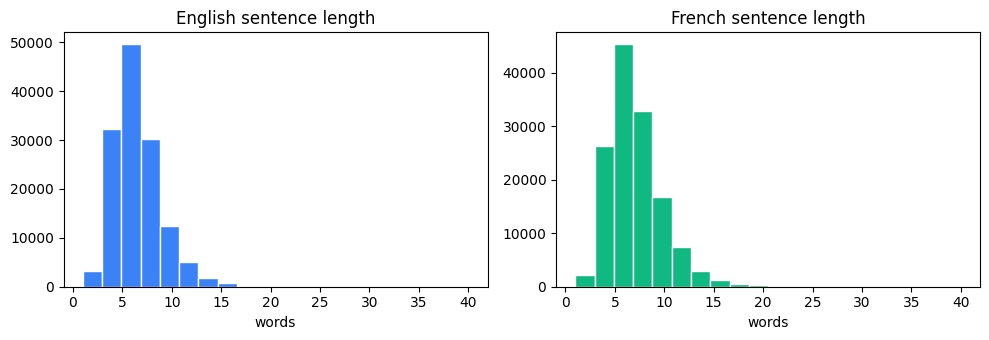

In [5]:
print(f"Pairs: {len(df):,}")
print("\nRandom examples:")
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f"  EN: {row['English']}")
    print(f"  FR: {row['French']}\n")

eng_lens = df["English"].astype(str).str.split().str.len()
fr_lens = df["French"].astype(str).str.split().str.len()
print(f"English words  — mean {eng_lens.mean():.1f}, max {eng_lens.max()}")
print(f"French words   — mean {fr_lens.mean():.1f}, max {fr_lens.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(eng_lens.clip(upper=40), bins=20, color="#3b82f6", edgecolor="white")
axes[0].set_title("English sentence length")
axes[0].set_xlabel("words")
axes[1].hist(fr_lens.clip(upper=40), bins=20, color="#10b981", edgecolor="white")
axes[1].set_title("French sentence length")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()


## 3. Text cleaning

Neural models need consistent input. We:

1. Lowercase everything (`Hi.` and `hi` should be the same token)
2. Expand a few common contractions (`don't` → `do not`)
3. Keep letters (and French accents) and spaces, drop the rest
4. Collapse repeated spaces

We do **not** add `<start>` / `<end>` here. Those special tokens are added later, when we convert text to IDs. That is cleaner than baking them into the raw strings.


In [6]:
EN_CONTRACTIONS = {
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
    "it's": "it is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "he'll": "he will", "she'll": "she will",
    "we'll": "we will", "they'll": "they will",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "let's": "let us",
}

FR_CONTRACTIONS = {
    "c'est": "ce est", "j'ai": "je ai", "n'est": "ne est",
    "qu'est": "que est", "d'accord": "de accord", "l'est": "le est",
}

# Letters we keep for French (accents + oe ligature)
FR_KEEP = r"a-zàâäçéèêëîïôùûüœÿ\s"


def _expand(text: str, table: dict) -> str:
    for src_tok, dst_tok in table.items():
        text = re.sub(rf"\b{re.escape(src_tok)}\b", dst_tok, text)
    return text


def clean_english(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, EN_CONTRACTIONS)
    text = re.sub(r"[^a-z\s]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_french(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, FR_CONTRACTIONS)
    text = re.sub(rf"[^{FR_KEEP}]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df["English"] = df["English"].map(clean_english)
df["French"] = df["French"].map(clean_french)
df = df[(df["English"].str.len() > 0) & (df["French"].str.len() > 0)].reset_index(drop=True)

print("After cleaning:")
for _, row in df.head(5).iterrows():
    print(f"  {row['English']:30s}  →  {row['French']}")


After cleaning:
  go                              →  va
  run                             →  cours
  run                             →  courez
  wow                             →  ça alors
  fire                            →  au feu


## 4. Train / validation / test split

We hold out **10% for test** (final numbers) and **10% of the remainder for validation** (early stopping). The vocabulary is built from the **training set only**, so the model never “sees” test words while building its dictionary.


In [7]:
train_df, test_df = train_test_split(df, test_size=0.10, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.10, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}")
print(f"Valid: {len(val_df):,}")
print(f"Test : {len(test_df):,}")


Train: 110,031
Valid: 12,226
Test : 13,585


## 5. Vocabulary and numericalization

A neural net cannot read strings. We map every word to an integer ID.

| Token | ID | Role |
|---|---|---|
| `<pad>` | 0 | Fills shorter sentences so a batch has one rectangular tensor |
| `<unk>` | 1 | Words that did not make the vocabulary cutoff |
| `<start>` | 2 | Tells the decoder “begin generating” |
| `<end>` | 3 | Tells the decoder “the sentence is finished” |

**Why `<start>` and `<end>`?**  
The decoder is a language model conditioned on the English sentence. It needs a first input token (`<start>`) and a stop signal (`<end>`). Without `<end>`, it would never know when to stop.


In [8]:
class Vocabulary:
    """Word-level vocabulary with reserved special tokens."""

    PAD = "<pad>"
    UNK = "<unk>"
    SOS = "<start>"
    EOS = "<end>"

    def __init__(self, max_size: int = 10_000):
        self.max_size = max_size
        self.word2idx = {self.PAD: 0, self.UNK: 1, self.SOS: 2, self.EOS: 3}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def build(self, sentences):
        counts = Counter()
        for sentence in sentences:
            counts.update(sentence.split())

        # Keep the most frequent words; reserve 4 slots for special tokens
        for word, _ in counts.most_common(self.max_size - 4):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        return self

    def encode(self, sentence: str, max_len: int, add_special: bool = False):
        tokens = sentence.split()
        if add_special:
            tokens = [self.SOS] + tokens + [self.EOS]
        ids = [self.word2idx.get(tok, self.word2idx[self.UNK]) for tok in tokens]
        ids = ids[:max_len]
        length = len(ids)
        ids = ids + [self.word2idx[self.PAD]] * (max_len - length)
        return ids, length

    def decode(self, ids, skip_special: bool = True):
        special = {self.PAD, self.UNK, self.SOS, self.EOS} if skip_special else set()
        words = []
        for idx in ids:
            word = self.idx2word.get(int(idx), self.UNK)
            if word == self.EOS:
                break
            if word in special:
                continue
            words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def sos_idx(self):
        return self.word2idx[self.SOS]

    @property
    def eos_idx(self):
        return self.word2idx[self.EOS]

    @property
    def unk_idx(self):
        return self.word2idx[self.UNK]


src_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["English"])
tgt_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["French"])

print(f"English vocab size: {len(src_vocab):,}")
print(f"French vocab size : {len(tgt_vocab):,}")
print("Sample English IDs:", list(src_vocab.word2idx.items())[:8])
print("Sample French IDs :", list(tgt_vocab.word2idx.items())[:8])


English vocab size: 10,000
French vocab size : 10,000
Sample English IDs: [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('i', 4), ('you', 5), ('to', 6), ('the', 7)]
Sample French IDs : [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('je', 4), ('de', 5), ('pas', 6), ('vous', 7)]


## 6bis. Modern word embeddings (FastText) — replacing the frequency-only representation

The original workshop notebook only used **frequency-based vocabulary building**: words were
kept purely based on how often they appeared, and the embedding layer itself was a randomly
initialized `nn.Embedding` with no notion of word meaning before training started. Two words
that never occur in the same context (e.g. `chat` and `chien`, "cat" and "dog") start out as
two unrelated random vectors.

Here we replace that with **FastText** embeddings (Bojanowski et al., 2017), trained directly
on the training split of our English/French corpus with `gensim`. FastText was chosen over
Word2Vec/GloVe because:

- It represents each word as a bag of **character n-grams**, so it can produce a reasonable
  vector for **rare and unseen (out-of-vocabulary) words** — important since our corpus is
  small and has many rare, everyday-language tokens.
- It naturally handles **morphologically related words** (`aime`, `aimer`, `aimons`), which is
  common in French.
- It can be trained quickly, locally, without needing an internet download of huge pretrained
  files (e.g. 300d GloVe/Word2Vec = several GB), which is a practical constraint on Kaggle.

We train **two separate FastText models** — one on English, one on French — since source and
target embeddings live in different vector spaces and are consumed by different modules
(encoder vs decoder). The resulting vectors are then used to **initialize** the `nn.Embedding`
layers of the encoder and decoder (instead of random initialization), and are fine-tuned
further during translation training.

In [9]:
import numpy as np
from gensim.models import FastText

FT_EMBED_DIM = CONFIG["embed_dim"]

def train_fasttext(sentences, embed_dim, epochs=10, min_count=1, window=5, seed=SEED):
    """Train a FastText model on a list of whitespace-tokenized sentences."""
    tokenized = [s.split() for s in sentences]
    model = FastText(
        sentences=tokenized,
        vector_size=embed_dim,
        window=window,
        min_count=min_count,
        workers=4,
        sg=1,          # skip-gram
        epochs=epochs,
        seed=seed,
    )
    return model


def build_embedding_matrix(vocab: "Vocabulary", ft_model: FastText, embed_dim: int) -> np.ndarray:
    """Build a (vocab_size, embed_dim) matrix aligned with `vocab`'s word2idx.

    Special tokens (<pad>/<unk>/<start>/<end>) get small random vectors; every other
    vocabulary word gets its FastText vector (FastText can produce a vector even for
    words outside the training data, via character n-grams).
    """
    rng = np.random.RandomState(SEED)
    matrix = rng.normal(scale=0.1, size=(len(vocab), embed_dim)).astype("float32")
    matrix[vocab.pad_idx] = np.zeros(embed_dim, dtype="float32")

    hits = 0
    for word, idx in vocab.word2idx.items():
        if word in {vocab.PAD, vocab.UNK, vocab.SOS, vocab.EOS}:
            continue
        try:
            matrix[idx] = ft_model.wv[word]
            hits += 1
        except KeyError:
            pass  # extremely unlikely with FastText, but keep the random fallback
    print(f"  matched {hits:,}/{len(vocab):,} vocabulary words directly in the FastText model")
    return matrix


print("Training FastText on the English training sentences ...")
ft_en = train_fasttext(train_df["English"].tolist(), FT_EMBED_DIM)
print("Training FastText on the French training sentences ...")
ft_fr = train_fasttext(train_df["French"].tolist(), FT_EMBED_DIM)

print("\nBuilding embedding matrices aligned with the vocabularies:")
src_embedding_matrix = build_embedding_matrix(src_vocab, ft_en, FT_EMBED_DIM)
tgt_embedding_matrix = build_embedding_matrix(tgt_vocab, ft_fr, FT_EMBED_DIM)

# Sanity check: nearest neighbours according to the trained FastText space
print("\nNearest neighbours to 'chat' (French FastText):", ft_fr.wv.most_similar("chat", topn=5))
print("Nearest neighbours to 'happy' (English FastText):", ft_en.wv.most_similar("happy", topn=5))


Training FastText on the English training sentences ...
Training FastText on the French training sentences ...

Building embedding matrices aligned with the vocabularies:
  matched 9,996/10,000 vocabulary words directly in the FastText model
  matched 9,996/10,000 vocabulary words directly in the FastText model

Nearest neighbours to 'chat' (French FastText): [('chaton', 0.874072790145874), ('chameau', 0.7912160158157349), ('chatte', 0.790469229221344), ('chagrin', 0.7814890742301941), ('char', 0.7682125568389893)]
Nearest neighbours to 'happy' (English FastText): [('unhappy', 0.9081376791000366), ('happily', 0.8000281453132629), ('happier', 0.7665335536003113), ('puppy', 0.7522075772285461), ('happiest', 0.7383354306221008)]


## 6. Dataset and DataLoader

Each training example is three tensors:

- `src` — English IDs, shape `(max_len,)`
- `tgt_in` — French IDs **with `<start>`**, used as decoder input
- `tgt_out` — French IDs **shifted left** (the next word the decoder should predict), ending with `<end>`

Example for `bonjour` (simplified):

```
tgt_in  = [<start>, bonjour, <end>, <pad>, ...]
tgt_out = [bonjour, <end>,   <pad>, <pad>, ...]
```

The model sees `tgt_in[t]` and must predict `tgt_out[t]`. That is **teacher forcing**: during training we feed the *correct* previous word, not the model’s own prediction. Training becomes much more stable.

> The original Keras notebook did the same thing by passing the full French sequence as decoder input and `french[:, 1:]` as the target.


In [10]:
class TranslationDataset(Dataset):
    def __init__(self, frame, src_vocab, tgt_vocab, max_len):
        self.src_texts = frame["English"].tolist()
        self.tgt_texts = frame["French"].tolist()
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src_ids, src_len = self.src_vocab.encode(
            self.src_texts[idx], self.max_len, add_special=False
        )
        tgt_ids, tgt_len = self.tgt_vocab.encode(
            self.tgt_texts[idx], self.max_len, add_special=True
        )
        # Decoder input = everything except the last token
        # Decoder target = everything except <start>
        tgt_in = tgt_ids[:-1]
        tgt_out = tgt_ids[1:]
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "src_len": torch.tensor(src_len, dtype=torch.long),
            "tgt_in": torch.tensor(tgt_in, dtype=torch.long),
            "tgt_out": torch.tensor(tgt_out, dtype=torch.long),
            "src_text": self.src_texts[idx],
            "tgt_text": self.tgt_texts[idx],
        }


def make_loader(frame, shuffle):
    dataset = TranslationDataset(frame, src_vocab, tgt_vocab, CONFIG["max_seq_len"])
    return DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        drop_last=False,
    )


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

batch = next(iter(train_loader))
print("Batch tensor shapes")
print(f"  src     {tuple(batch['src'].shape)}     # (batch, src_len)")
print(f"  tgt_in  {tuple(batch['tgt_in'].shape)}  # (batch, tgt_len - 1)")
print(f"  tgt_out {tuple(batch['tgt_out'].shape)} # (batch, tgt_len - 1)")
print()
print("Text :", batch["src_text"][0], "→", batch["tgt_text"][0])
print("src  :", batch["src"][0].tolist()[:12])
print("in   :", batch["tgt_in"][0].tolist()[:12])
print("out  :", batch["tgt_out"][0].tolist()[:12])


Batch tensor shapes
  src     (64, 40)     # (batch, src_len)
  tgt_in  (64, 39)  # (batch, tgt_len - 1)
  tgt_out (64, 39) # (batch, tgt_len - 1)

Text : he has more money than can be spent → il a plus d argent qu on ne peut en dépenser
src  : [13, 67, 90, 110, 102, 43, 32, 607, 0, 0, 0, 0]
in   : [2, 9, 18, 40, 25, 119, 33, 80, 11, 100, 22, 2405]
out  : [9, 18, 40, 25, 119, 33, 80, 11, 100, 22, 2405, 3]


## 7. Model: Seq2Seq with attention

### 7.1 Why encoder–decoder?

Translation is a **sequence-to-sequence** problem: the input and output have different lengths and different word orders.

```
English (source)          French (target)
I     love   cats    →    j'   aime   les   chats
```

A single LSTM that reads English and immediately writes French would struggle, because it would have to start generating before it has seen the full source sentence. The encoder–decoder split fixes that:

- The **encoder** reads the *entire* English sentence first
- The **decoder** then writes French, looking back at the encoder memory

### 7.2 Bidirectional LSTM encoder

A normal LSTM reads left → right. A **bidirectional** LSTM also reads right → left, then concatenates both hidden states.

That helps because the meaning of a word often depends on both sides:

`bank` in `river bank` vs `bank account`

Encoder hidden size is `256` per direction, so the concatenated state is `512`. The decoder LSTM therefore uses hidden size `512` so it can be initialized from those states.

### 7.3 Luong / dot-product attention

The original “bottleneck” Seq2Seq compressed the whole sentence into one vector. Attention lets the decoder **look at every encoder step** and pick what is relevant.

For one decoder step, with query \(q\) (decoder hidden) and encoder memory \(K\) (all encoder outputs):

$$
\text{scores} = q \cdot K^\top
$$

$$
\alpha = \mathrm{softmax}(\text{scores})
$$

$$
\text{context} = \alpha \cdot V
$$

Intuition: \(\alpha\) is a probability distribution over English words. The context vector is a weighted summary of the source sentence for *this* French word.

We then concatenate `[decoder_output ; context]` and project to the French vocabulary.

This is the same idea as the custom `AttentionLayer` in the TensorFlow notebook, with one important upgrade: **we mask pad positions** so the model cannot attend to padding.


In [11]:
class Encoder(nn.Module):
    """Bidirectional LSTM encoder.

    Input : (batch, src_len) token IDs
    Output: encoder_outputs (batch, src_len, 2*hidden)
            hidden, cell    (1, batch, 2*hidden)  — merged directions
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_embeddings is not None:
            # Initialize with FastText vectors instead of random weights
            weight = torch.tensor(pretrained_embeddings, dtype=torch.float32)
            self.embedding = nn.Embedding.from_pretrained(
                weight, freeze=freeze_embeddings, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (B, S)
        embedded = self.dropout(self.embedding(src))          # (B, S, E)
        outputs, (hidden, cell) = self.lstm(embedded)         # outputs: (B, S, 2H)
        # hidden/cell come as (2, B, H) = [forward; backward]
        hidden = torch.cat([hidden[0], hidden[1]], dim=-1).unsqueeze(0)  # (1, B, 2H)
        cell = torch.cat([cell[0], cell[1]], dim=-1).unsqueeze(0)
        return outputs, hidden, cell


class LuongAttention(nn.Module):
    """Dot-product attention with optional padding mask."""

    def forward(self, decoder_outputs, encoder_outputs, src_mask=None):
        # decoder_outputs: (B, T, H)
        # encoder_outputs: (B, S, H)
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))  # (B, T, S)
        if src_mask is not None:
            # src_mask: (B, S) True = keep, False = pad
            scores = scores.masked_fill(~src_mask.unsqueeze(1), -1e9)
        weights = F.softmax(scores, dim=-1)                   # (B, T, S)
        context = torch.bmm(weights, encoder_outputs)         # (B, T, H)
        return context, weights


class Decoder(nn.Module):
    """LSTM decoder + attention + vocab projection.

    Works on a full target sequence (training) or a single token (inference).
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        if pretrained_embeddings is not None:
            weight = torch.tensor(pretrained_embeddings, dtype=torch.float32)
            self.embedding = nn.Embedding.from_pretrained(
                weight, freeze=freeze_embeddings, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True)
        self.attention = LuongAttention()
        # concat(decoder_out, context) → vocab
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_in, hidden, cell, encoder_outputs, src_mask=None):
        embedded = self.dropout(self.embedding(tgt_in))       # (B, T, E)
        dec_out, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # (B, T, H)
        context, attn = self.attention(dec_out, encoder_outputs, src_mask)
        combined = torch.cat([dec_out, context], dim=-1)      # (B, T, 2H)
        logits = self.fc(combined)                            # (B, T, V)
        return logits, hidden, cell, attn


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def create_src_mask(self, src):
        return src != self.pad_idx  # (B, S) True = real token

    def forward(self, src, tgt_in):
        encoder_outputs, hidden, cell = self.encoder(src)
        src_mask = self.create_src_mask(src)
        logits, _, _, attn = self.decoder(
            tgt_in, hidden, cell, encoder_outputs, src_mask
        )
        return logits, attn


In [12]:
encoder = Encoder(
    vocab_size=len(src_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    pad_idx=src_vocab.pad_idx,
    dropout=CONFIG["dropout"],
    pretrained_embeddings=src_embedding_matrix,   # FastText init instead of random
    freeze_embeddings=False,                      # fine-tuned further during training
)
decoder = Decoder(
    vocab_size=len(tgt_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["decoder_hidden"],
    pad_idx=tgt_vocab.pad_idx,
    dropout=CONFIG["dropout"],
    pretrained_embeddings=tgt_embedding_matrix,   # FastText init instead of random
    freeze_embeddings=False,
)
model = Seq2Seq(encoder, decoder, pad_idx=src_vocab.pad_idx).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256, padding_idx=0)
    (lstm): LSTM(256, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 256, padding_idx=0)
    (lstm): LSTM(256, 512, batch_first=True)
    (attention): LuongAttention()
    (fc): Linear(in_features=1024, out_features=10000, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

Trainable parameters: 17,999,632


## 8. Loss, metrics, and the padding trap

We use **cross-entropy** over the French vocabulary.

**Important workshop point:** the original Keras notebook reported ~96% accuracy. A large part of that number came from **padding tokens**. If 70% of a batch is `<pad>` and the model learns to predict pad after `<end>`, accuracy looks excellent even when the real words are mediocre.

In PyTorch we pass `ignore_index=PAD` so pad positions do **not** contribute to the loss or to our token accuracy. The number will look lower — and more honest.


In [13]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)


def token_accuracy(logits, targets, pad_idx):
    """Accuracy on non-pad tokens only."""
    preds = logits.argmax(dim=-1)
    mask = targets != pad_idx
    if mask.sum() == 0:
        return 0.0
    return (preds[mask] == targets[mask]).float().mean().item()


def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            src = batch["src"].to(device)
            tgt_in = batch["tgt_in"].to(device)
            tgt_out = batch["tgt_out"].to(device)

            logits, _ = model(src, tgt_in)  # (B, T, V)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            total_loss += loss.item()
            total_acc += token_accuracy(logits, tgt_out, tgt_vocab.pad_idx)
            n_batches += 1

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


## 9. Training loop

Each epoch:

1. Encode English
2. Decode the full French sequence in one shot (teacher forcing)
3. Compare predicted tokens with `tgt_out`
4. Backpropagate, clip gradients, step the optimizer

**Early stopping** watches validation loss. If it does not improve for `patience` epochs, we restore the best weights and stop. That is the PyTorch equivalent of Keras `EarlyStopping(restore_best_weights=True)`.

**Gradient clipping** (`max_norm=1.0`) keeps LSTM training from exploding — a classic RNN issue.


In [14]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = math.inf
best_state = None
stale = 0
t0 = time.time()

print(f"{'epoch':>6}  {'train_loss':>11}  {'val_loss':>9}  {'train_acc':>10}  {'val_acc':>8}  {'time':>6}")
print("-" * 64)

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - epoch_start
    print(
        f"{epoch:6d}  {train_loss:11.4f}  {val_loss:9.4f}  "
        f"{train_acc:10.3f}  {val_acc:8.3f}  {elapsed:5.0f}s"
    )

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stale = 0
    else:
        stale += 1
        if stale >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch} (best val loss = {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"\nFinished in {(time.time() - t0) / 60:.1f} min. Best val loss: {best_val:.4f}")


 epoch   train_loss   val_loss   train_acc   val_acc    time
----------------------------------------------------------------
     1       2.6807     1.5494       0.518     0.666    119s
     2       1.2770     1.2336       0.704     0.719    129s
     3       0.9498     1.1412       0.758     0.736    128s
     4       0.7779     1.1120       0.790     0.746    129s
     5       0.6633     1.1036       0.814     0.749    130s
     6       0.5842     1.1059       0.832     0.754    130s
     7       0.5240     1.1160       0.846     0.756    130s
     8       0.4010     1.0828       0.876     0.764    130s
     9       0.3547     1.0927       0.887     0.763    130s
    10       0.3290     1.1140       0.894     0.764    130s
    11       0.2763     1.1085       0.908     0.766    130s
Early stopping at epoch 11 (best val loss = 1.0828)

Finished in 23.6 min. Best val loss: 1.0828


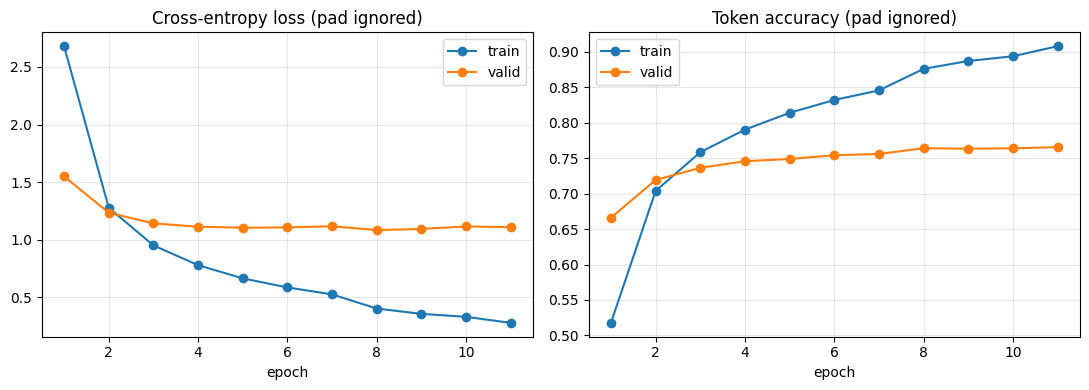

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_x, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_x, history["val_loss"], marker="o", label="valid")
axes[0].set_title("Cross-entropy loss (pad ignored)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_x, history["val_acc"], marker="o", label="valid")
axes[1].set_title("Token accuracy (pad ignored)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluation on the test set

Same metric as validation: loss and token accuracy, **padding ignored**.


In [16]:
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}   ← non-pad French tokens only")


Test loss:     1.0724
Test accuracy: 0.765   ← non-pad French tokens only


## 10bis. Machine-translation metrics: BLEU and ROUGE

Token accuracy tells us how often the model predicts the *exact* next gold token when fed
the *true* previous tokens (teacher forcing). That is not how translation is judged in
practice, and it is not computed on the model's own free-running output. For a proper
evaluation we generate translations with **greedy decoding** (no teacher forcing) and score
them against the human reference with two standard MT metrics:

- **BLEU** (Bilingual Evaluation Understudy) — measures **n-gram precision** between the
  candidate and the reference (how many of the candidate's 1-, 2-, 3-, 4-grams also appear in
  the reference), combined with a **brevity penalty** so that very short outputs cannot get an
  artificially high score. BLEU is the most widely reported metric for MT and ranges from 0
  to 100 (or 0–1); higher is better.
- **ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) — originally designed for
  summarization, but useful here as a complementary, **recall-oriented** view: ROUGE-1/ROUGE-2
  measure unigram/bigram overlap, and ROUGE-L measures the **longest common subsequence**,
  which rewards preserving word order even when exact n-grams don't match.

Together, BLEU (precision-heavy, n-gram based) and ROUGE (recall-heavy, LCS-based) give a
more balanced picture than either metric alone.

In [20]:
import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

smoothing = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)


@torch.no_grad()
def translate_sentence(sentence: str, max_len: int = None, return_attention: bool = False):
    """Greedy decode one English sentence → French string."""
    model.eval()
    max_len = max_len or CONFIG["max_seq_len"]

    cleaned = clean_english(sentence)
    src_ids, src_len = src_vocab.encode(cleaned, CONFIG["max_seq_len"], add_special=False)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, S)

    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.create_src_mask(src)

    token = torch.tensor([[tgt_vocab.sos_idx]], device=device)  # (1, 1)
    output_ids = []
    attn_steps = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(
            token, hidden, cell, encoder_outputs, src_mask
        )
        next_id = int(logits[0, -1].argmax())
        attn_steps.append(attn[0, 0, :src_len].detach().cpu())
        if next_id == tgt_vocab.eos_idx:
            break
        output_ids.append(next_id)
        token = torch.tensor([[next_id]], device=device)

    text = tgt_vocab.decode(output_ids)
    if return_attention:
        attn_mat = torch.stack(attn_steps, dim=0) if attn_steps else torch.zeros(1, src_len)
        src_tokens = cleaned.split()[:src_len]
        tgt_tokens = text.split()
        return text, src_tokens, tgt_tokens, attn_mat
    return text


@torch.no_grad()
def evaluate_bleu_rouge(frame, n=None, seed=0):
    """Greedy-decode `n` (or all) sentences from `frame` and score against references."""
    model.eval()
    if n is not None and n < len(frame):
        frame = frame.sample(n=n, random_state=seed).reset_index(drop=True)

    references, hypotheses = [], []
    rouge1_f, rouge2_f, rougeL_f = [], [], []

    for _, row in frame.iterrows():
        ref_text = row["French"]
        hyp_text = translate_sentence(row["English"])

        ref_tokens = ref_text.split()
        hyp_tokens = hyp_text.split()
        references.append([ref_tokens])
        hypotheses.append(hyp_tokens)

        scores = rouge.score(ref_text, hyp_text)
        rouge1_f.append(scores["rouge1"].fmeasure)
        rouge2_f.append(scores["rouge2"].fmeasure)
        rougeL_f.append(scores["rougeL"].fmeasure)

    bleu = corpus_bleu(references, hypotheses, smoothing_function=smoothing)
    results = {
        "BLEU": bleu,
        "ROUGE-1 (F1)": sum(rouge1_f) / len(rouge1_f),
        "ROUGE-2 (F1)": sum(rouge2_f) / len(rouge2_f),
        "ROUGE-L (F1)": sum(rougeL_f) / len(rougeL_f),
        "n_sentences": len(frame),
    }
    return results


# Full test-set BLEU/ROUGE (can be slow on CPU for the full set — subsample if needed)
EVAL_SUBSET = 1000 if len(test_df) > 1000 else None
mt_metrics = evaluate_bleu_rouge(test_df, n=EVAL_SUBSET, seed=SEED)

print(f"Evaluated on {mt_metrics['n_sentences']:,} test sentences (greedy decoding)\n")
print(f"  BLEU        : {mt_metrics['BLEU']:.4f}")
print(f"  ROUGE-1 (F1): {mt_metrics['ROUGE-1 (F1)']:.4f}")
print(f"  ROUGE-2 (F1): {mt_metrics['ROUGE-2 (F1)']:.4f}")
print(f"  ROUGE-L (F1): {mt_metrics['ROUGE-L (F1)']:.4f}")


Evaluated on 1,000 test sentences (greedy decoding)

  BLEU        : 0.4375
  ROUGE-1 (F1): 0.6911
  ROUGE-2 (F1): 0.5097
  ROUGE-L (F1): 0.6821


## 11. Inference: translating a new sentence

Training used teacher forcing (the correct previous French word).  
**Inference cannot do that** — we do not have the French sentence yet.

Greedy decoding:

1. Encode the English sentence once
2. Feed `<start>` to the decoder
3. Pick the most likely next word (`argmax`)
4. Feed that word back in
5. Repeat until `<end>` or `max_len`

This is slower than training (one token per step) but it is how the model is actually used.

We also return the attention matrix so we can draw a heatmap: rows = generated French words, columns = English words.


In [21]:
@torch.no_grad()
def translate_sentence(sentence: str, max_len: int = None, return_attention: bool = False):
    """Greedy decode one English sentence → French string."""
    model.eval()
    max_len = max_len or CONFIG["max_seq_len"]

    cleaned = clean_english(sentence)
    src_ids, src_len = src_vocab.encode(cleaned, CONFIG["max_seq_len"], add_special=False)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, S)

    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.create_src_mask(src)

    token = torch.tensor([[tgt_vocab.sos_idx]], device=device)  # (1, 1)
    output_ids = []
    attn_steps = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(
            token, hidden, cell, encoder_outputs, src_mask
        )
        next_id = int(logits[0, -1].argmax())
        attn_steps.append(attn[0, 0, :src_len].detach().cpu())
        if next_id == tgt_vocab.eos_idx:
            break
        output_ids.append(next_id)
        token = torch.tensor([[next_id]], device=device)

    text = tgt_vocab.decode(output_ids)
    if return_attention:
        attn_mat = torch.stack(attn_steps, dim=0) if attn_steps else torch.zeros(1, src_len)
        src_tokens = cleaned.split()[:src_len]
        tgt_tokens = text.split()
        return text, src_tokens, tgt_tokens, attn_mat
    return text


def plot_attention(src_tokens, tgt_tokens, attn_mat, title="Attention"):
    if len(src_tokens) == 0 or len(tgt_tokens) == 0:
        print("Nothing to plot (empty translation).")
        return
    # attn_mat may have one extra row if we stopped on <end>
    rows = min(len(tgt_tokens), attn_mat.size(0))
    mat = attn_mat[:rows, :len(src_tokens)].numpy()

    fig, ax = plt.subplots(figsize=(max(4, 0.55 * len(src_tokens) + 2), max(3, 0.45 * rows + 1.5)))
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right")
    ax.set_yticks(range(rows))
    ax.set_yticklabels(tgt_tokens[:rows])
    ax.set_xlabel("English (source)")
    ax.set_ylabel("French (generated)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


print(translate_sentence("I am very happy today"))
print(translate_sentence("Where is the parking?"))


je suis très heureuse aujourd hui
où se trouve le


## 12. Qualitative results

Random test sentences: reference vs model output. Short, frequent phrases are usually better than long / rare ones — that is expected for a from-scratch LSTM on a limited vocabulary.


In [22]:
def show_translations(n=10, seed=0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(test_df)), k=min(n, len(test_df)))
    rows = []
    for i in indices:
        eng = test_df.loc[i, "English"]
        ref = test_df.loc[i, "French"]
        pred = translate_sentence(eng)
        rows.append({"English": eng, "Reference (FR)": ref, "Predicted (FR)": pred})
    return pd.DataFrame(rows)


translations_df = show_translations(n=12, seed=7)
pd.set_option("display.max_colwidth", 80)
translations_df


,English,Reference (FR),Predicted (FR)
0,he made up a story about the dog,il inventa une histoire au sujet du chien,il a inventé une histoire à propos du chien
1,i argued with him about it,je me suis disputé avec lui à ce propos,je m en suis disputée avec lui
2,there is nothing like cold beer on a hot day,il n y a rien de tel qu une bière fraîche un jour de canicule,il n y a rien de frais à vent de frais
3,i know the reason but i cannot tell you,je connais la raison mais je ne peux pas vous la dire,je sais la raison mais je ne peux pas te la dire
4,my children do not listen to me,mes enfants ne m écoutent pas,mes enfants m adorent m écouter
5,i got dumped,je ai été larguée,je ai été largué
6,can you determine what happened,peux tu déterminer ce qui s est passé,pouvez vous déterminer ce qui s est passé
7,i wish him the very best in his future endeavors,je lui souhaite le meilleur dans ses futures entreprises,je lui souhaite de très mieux dans ses futures entreprises
8,tom is always watching tv,tom regarde toujours la télévision,tom regarde la télé regarde
9,i will leave it up to you,je vous laisse la décision,je vous laisserai la décision


### Attention heatmap

Bright cells mean: “when I generated this French word, I was looking at that English word.” For a well-trained model you often see a roughly diagonal pattern, with extra mass on words like *not* / *ne* that flip meaning.


EN : it is pitch black outside
FR : il fait noir comme dans un four dehors


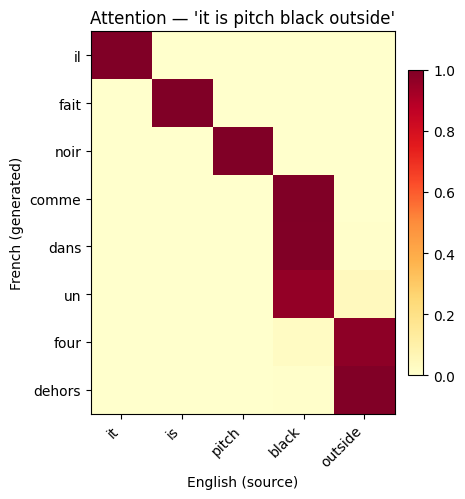

In [23]:
demo_sentence = test_df.sample(1, random_state=1).iloc[0]["English"]
pred, src_toks, tgt_toks, attn = translate_sentence(demo_sentence, return_attention=True)
print(f"EN : {demo_sentence}")
print(f"FR : {pred}")
plot_attention(src_toks, tgt_toks, attn, title=f"Attention — '{demo_sentence}'")


## 13. Try your own sentences

Type any short English sentence. Keep it close to everyday spoken English — that is what this corpus looks like.


In [24]:
your_sentences = [
    "Hi.",
    "Run!",
    "I love you.",
    "Where is the bathroom?",
    "I am not ready yet.",
    "Can you help me please?",
]

for s in your_sentences:
    print(f"{s:28s} →  {translate_sentence(s)}")


Hi.                          →  salut
Run!                         →  courez
I love you.                  →  je t aime
Where is the bathroom?       →  où sont les toilettes
I am not ready yet.          →  je ne suis pas encore prêt
Can you help me please?      →  pouvez vous m aider s il vous plaît


## 14. Save the model

You can reload `seq2seq_en_fr.pt` later without retraining. The checkpoint stores vocabularies as well, because IDs are meaningless without them.


In [25]:
ckpt_path = Path("seq2seq_en_fr.pt")
torch.save(
    {
        "model_state": model.state_dict(),
        "config": CONFIG,
        "src_word2idx": src_vocab.word2idx,
        "tgt_word2idx": tgt_vocab.word2idx,
    },
    ckpt_path,
)
print(f"Saved checkpoint → {ckpt_path.resolve()}")


Saved checkpoint → /content/seq2seq_en_fr.pt


## 15. Workshop recap

| Piece | What it did |
|---|---|
| FastText embeddings | Initialized encoder/decoder embeddings from corpus-trained FastText vectors (replacing random/frequency-only init) |
| Cleaning | Normalized text so `Don't` and `do not` look the same |
| Vocabulary | Mapped words ↔ IDs, with `<pad> / <unk> / <start> / <end>` |
| Encoder (BiLSTM) | Read English forwards and backwards |
| Attention | Let each French word look at the relevant English words |
| Decoder (LSTM) | Wrote French one token at a time |
| Teacher forcing | Fed the true previous word during training |
| Greedy decode | Fed the model’s own previous word at test time |
| `ignore_index` | Stopped padding from inflating accuracy |
| BLEU / ROUGE | Scored greedy-decoded translations against references with standard MT metrics |

### Natural next steps (if you have extra time)
- **Beam search** instead of greedy decoding — keep the top-\(k\) hypotheses
- **Scheduled sampling** — mix gold tokens and model tokens during training
- **BLEU / chrF** — standard MT metrics (token accuracy is only a proxy)
- **Subword tokenization** (BPE / SentencePiece) — handles rare words better than a hard 8k vocab
- **Transformers** — replace LSTMs with self-attention (the modern default), You will now that topic in the next session.
